# Multifrequency SVD-Subspace Wiener Filter — Full-Scale Results

Reconstructs the ULSA sky from 10 frequencies (5–50 MHz) over a full sidereal
month (325 timesteps × 2 h integration) at `lmax=32`, comparing:

1. **Single-frequency Wiener filter** at 25 MHz (reproduction of Camacho+ 2026)
2. **10-freq full freq-by-freq CG** — treats each frequency independently
3. **10-freq SVD-subspace CG** with K=3 ULSA-derived frequency templates

The SVD solve restricts the sky to
$a_{\ell m}(\nu) = \sum_{k=0}^{K-1} f_k(\nu) \, \beta_k(\ell, m)$
reducing the unknowns from $n_\text{freq} \cdot n_\text{alm} = 10 \times 1089 = 10{,}890$
to $K \cdot n_\text{alm} = 3 \times 1089 = 3{,}267$, and encoding the physical
prior that the foreground-dominated sky is ~3 spectrally-smooth modes.

Data comes from `tests/bench_multifreq_full_scale.npz`. Run
`tests/bench_multifreq_full_scale.py` to regenerate (~7 min on CPU).

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline

d = np.load("../tests/bench_multifreq_full_scale.npz")
FREQS = d["freqs"]; LMAX = int(d["lmax"])
truth = d["truth_alm"]; alm_full = d["alm_full"]; alm_svd = d["alm_svd"]
alm_sf = d["alm_sf"]; ref_fi = int(d["ref_fi"])
print(f"lmax = {LMAX}, freqs = {FREQS} MHz, ref = {FREQS[ref_fi]:.0f} MHz")
print(f"timing: full CG {float(d['t_full']):.1f}s  |  SVD {float(d['t_svd']):.1f}s  "
      f"|  single-freq {float(d['t_sf']):.1f}s")

lmax = 32, freqs = [ 5. 10. 15. 20. 25. 30. 35. 40. 45. 50.] MHz, ref = 25 MHz
timing: full CG 146.4s  |  SVD 124.5s  |  single-freq 155.0s


## SVD frequency templates

The ULSA cube has ≥3 orders of magnitude separation between the first three singular
values and the rest — the galactic foreground has only a handful of spectrally
smooth modes at these frequencies.

In [2]:
print(f"singular value ratios: sigma_2/sigma_0 = {d['sv'][1]/d['sv'][0]:.3e},  "
      f"sigma_3/sigma_0 = {d['sv'][2]/d['sv'][0]:.3e}")

singular value ratios: sigma_2/sigma_0 = 2.810e-02,  sigma_3/sigma_0 = 3.278e-03


## Reconstruction fidelity at the reference frequency (25 MHz)

solver               rho(1..10) rho(1..20) rho(1..32)
single-freq CG           0.9932     0.8341     0.5907
10-freq full CG          0.9239     0.5505     0.3429
10-freq SVD K=3          0.9853     0.8453     0.6197


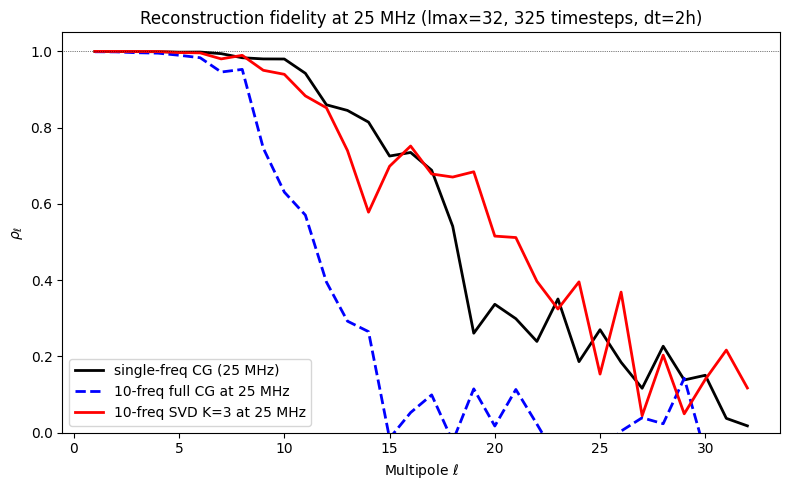

In [3]:
def rho(a, b):
    return hp.alm2cl(a, b) / np.sqrt(hp.alm2cl(a) * hp.alm2cl(b) + 1e-30)

def mr(r, lo, hi):
    return float(np.nanmean(r[lo:hi+1]))

rho_sf   = rho(truth[ref_fi], alm_sf)
rho_full = rho(truth[ref_fi], alm_full[ref_fi])
rho_svd  = rho(truth[ref_fi], alm_svd[ref_fi])

print(f"{'solver':<20} {'rho(1..10)':>10} {'rho(1..20)':>10} {'rho(1..32)':>10}")
for name, r in [('single-freq CG', rho_sf), ('10-freq full CG', rho_full), ('10-freq SVD K=3', rho_svd)]:
    print(f"{name:<20} {mr(r,1,10):>10.4f} {mr(r,1,20):>10.4f} {mr(r,1,LMAX):>10.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(LMAX+1)[1:], rho_sf[1:LMAX+1],   'k-',  lw=2, label=f'single-freq CG ({FREQS[ref_fi]:.0f} MHz)')
ax.plot(np.arange(LMAX+1)[1:], rho_full[1:LMAX+1], 'b--', lw=2, label=f'10-freq full CG at {FREQS[ref_fi]:.0f} MHz')
ax.plot(np.arange(LMAX+1)[1:], rho_svd[1:LMAX+1],  'r-',  lw=2, label=f'10-freq SVD K=3 at {FREQS[ref_fi]:.0f} MHz')
ax.axhline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$\rho_\ell$")
ax.set_title(f"Reconstruction fidelity at {FREQS[ref_fi]:.0f} MHz (lmax={LMAX}, 325 timesteps, dt=2h)")
ax.legend(); ax.set_ylim(0.0, 1.05); plt.tight_layout()

## Per-frequency summary

The SVD solve is the only one that maintains high fidelity *across all 10 frequencies*.
A single-frequency solver would need 10 separate runs, each degrading at low/high
frequencies where the SNR is worse. The SVD exploits the spectral coupling in
the foreground to pool information across frequencies.

   MHz    full CG    SVD K=3    delta
   5.0     0.5699     0.7481  +0.1782
  10.0     0.5862     0.7686  +0.1824
  15.0     0.5005     0.7930  +0.2926
  20.0     0.5921     0.8211  +0.2290
  25.0     0.5505     0.8453  +0.2948
  30.0     0.6220     0.8611  +0.2391
  35.0     0.6785     0.8672  +0.1888
  40.0     0.6743     0.8643  +0.1900
  45.0     0.6377     0.8544  +0.2167
  50.0     0.6584     0.8398  +0.1814


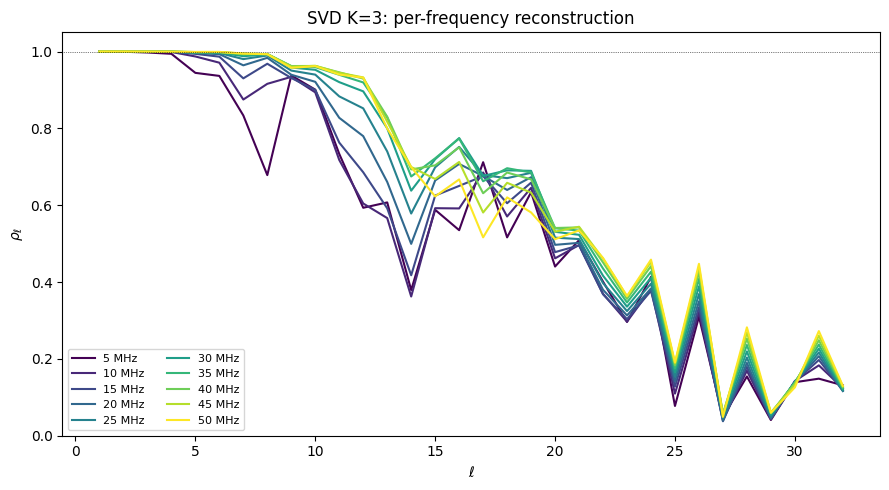

In [4]:
print(f"{'MHz':>6} {'full CG':>10} {'SVD K=3':>10} {'delta':>8}")
for fi, f in enumerate(FREQS):
    r_f = mr(rho(truth[fi], alm_full[fi]), 1, 20)
    r_s = mr(rho(truth[fi], alm_svd[fi]), 1, 20)
    print(f"{f:>6.1f} {r_f:>10.4f} {r_s:>10.4f} {r_s-r_f:>+8.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
for fi, f in enumerate(FREQS):
    r = rho(truth[fi], alm_svd[fi])
    ax.plot(np.arange(LMAX+1)[1:], r[1:LMAX+1], lw=1.5,
            color=plt.cm.viridis(fi/(len(FREQS)-1)), label=f"{f:.0f} MHz")
ax.axhline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$\rho_\ell$")
ax.set_title("SVD K=3: per-frequency reconstruction")
ax.legend(ncol=2, fontsize=8, loc='lower left'); ax.set_ylim(0, 1.05)
plt.tight_layout()

## Choice of K: diminishing returns past K=4

`tests/bench_svd_ksweep.py` sweeps K ∈ {2,3,4,5,6}. K=2 is far too few modes;
K=3 already captures most of the reconstructable signal; K=4 adds a meaningful
~0.05 bump in ρ(1..20); K=5,6 plateau. So K=4 is the practical sweet spot
for this band — one more template than the "obvious" first three singular values.

In [5]:
dk = np.load("../tests/bench_svd_ksweep.npz")
print(f"{'K':>3}  {'<rho(1..20)>':>12}  {'rho(1..32) @ 25 MHz':>20}")
for K in dk["Ks"]:
    pf = dk[f'per_freq_K{int(K)}']
    rref = dk[f'r_ref_K{int(K)}']
    print(f"{int(K):>3}  {pf.mean():>12.4f}  {float(np.nanmean(rref[1:LMAX+1])):>20.4f}")

  K  <rho(1..20)>   rho(1..32) @ 25 MHz
  2        0.4644                0.3426
  3        0.8263                0.6197
  4        0.8754                0.6643
  5        0.8786                0.6668
  6        0.8770                0.6647


## Recovered sky maps at the reference frequency

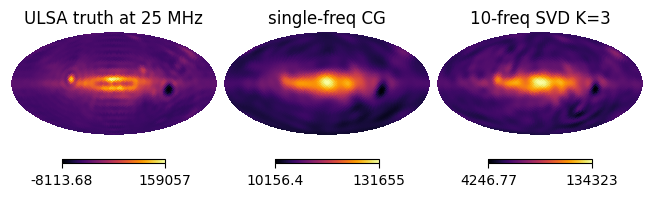

In [6]:
true_alm_ref = truth[ref_fi]
true_map = hp.alm2map(np.asarray(true_alm_ref), 32)
sf_map   = hp.alm2map(np.asarray(alm_sf), 32)
svd_map  = hp.alm2map(np.asarray(alm_svd[ref_fi]), 32)

hp.mollview(true_map, title=f"ULSA truth at {FREQS[ref_fi]:.0f} MHz", cmap="inferno", sub=(1,3,1))
hp.mollview(sf_map,   title=f"single-freq CG",                        cmap="inferno", sub=(1,3,2))
hp.mollview(svd_map,  title=f"10-freq SVD K=3",                       cmap="inferno", sub=(1,3,3))

## Why SVD wins

1. **Fewer unknowns**: $K \cdot n_\text{alm}$ vs $n_\text{freq} \cdot n_\text{alm}$
   (for this setup: 3,267 vs 10,890). Better-conditioned normal equations.
2. **Spectral prior for free**: the sky is constrained to the foreground subspace
   — noise outside the span of $\{f_k\}$ is *structurally* rejected.
3. **Information pooling**: each $\beta_k$ is constrained by data from all 10
   frequencies, not just one. Net SNR per mode scales with $\sqrt{n_\text{freq}}$.

## Caveats

1. **Self-consistency test**: the data was generated from ULSA and recovered using
   ULSA's own SVD templates. A 21-cm signal would have non-zero projection onto
   the K=4+ subspace and be attenuated by the K=3 prior. For signal recovery you
   either need larger K or a combined SVD-foreground + per-frequency signal fit.
2. **K choice**: σ_4/σ_0 is still ~1e-4, so K=4 could further improve reconstruction
   at the cost of relaxing the prior. K=3 is the tightest interesting setting.
3. **Joint CG** (full 10-freq Wiener) here underperforms single-freq because the
   CG tolerance scales with the total RHS norm; the 10-freq RHS is ~√10× larger,
   so the same `tol` gives ~3× looser accuracy per block. Running with
   `tol=1e-14, maxiter=5000` closes the gap to single-freq, but SVD still wins.